<a href="https://colab.research.google.com/github/halimAhtasham/Network-_Intrusion_Detection---All_In_One/blob/main/01_Random_Forest_ROSIDS23_Leakage_Free.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **01. Random Forest Environment Setup**

In [1]:
# ============================================================
# BLOCK 1
# Final Random Forest Experimental Environment Setup
# ROSIDS23 Leakage-Free IDS Framework
# IEEE Research Implementation
# ============================================================


# ============================================================
# 1. Mount Google Drive
# ============================================================

from google.colab import drive

drive.mount('/content/drive')


# ============================================================
# 2. Define Project Paths
# ============================================================

import os


BASE_PATH = "/content/drive/MyDrive/ROSID"


# Processed dataset path
PROCESSED_PATH = os.path.join(
    BASE_PATH,
    "Processed"
)


# Model saving path
MODEL_PATH = os.path.join(
    BASE_PATH,
    "Model",
    "Random Forest"
)


# CSV result saving path
RESULT_PATH = os.path.join(
    BASE_PATH,
    "CSV",
    "Random Forest"
)


# Figure saving path
FIGURE_PATH = os.path.join(
    BASE_PATH,
    "Figure",
    "Random Forest"
)



# Create folders

os.makedirs(
    MODEL_PATH,
    exist_ok=True
)


os.makedirs(
    RESULT_PATH,
    exist_ok=True
)


os.makedirs(
    FIGURE_PATH,
    exist_ok=True
)



print("Processed Dataset Path:")
print(PROCESSED_PATH)


print("\nModel Path:")
print(MODEL_PATH)


print("\nResult Path:")
print(RESULT_PATH)


print("\nFigure Path:")
print(FIGURE_PATH)



# ============================================================
# 3. Import Libraries
# ============================================================


# Data processing

import numpy as np
import pandas as pd



# Visualization

import matplotlib.pyplot as plt
import seaborn as sns



# Time measurement

import time



# File handling

import json
import joblib



# Machine Learning

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer


from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GroupKFold
)



from sklearn.preprocessing import LabelEncoder



# Random Forest

from sklearn.ensemble import RandomForestClassifier



# Evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)



# ============================================================
# 4. Warning Control
# ============================================================

import warnings

warnings.filterwarnings(
    "ignore"
)



# ============================================================
# 5. Reproducibility Settings
# ============================================================


RANDOM_STATE = 42


np.random.seed(
    RANDOM_STATE
)



# ============================================================
# 6. IEEE Figure Configuration
# ============================================================


plt.rcParams.update({

    "font.family": "Times New Roman",

    "font.size": 10,

    "axes.labelsize": 10,

    "axes.titlesize": 11,

    "xtick.labelsize": 9,

    "ytick.labelsize": 9,

    "legend.fontsize": 9,

    "figure.dpi": 300

})



# ============================================================
# 7. Environment Check
# ============================================================


print("\n========== Environment Ready ==========")

print(
    "Random State:",
    RANDOM_STATE
)


print(
    "Scikit-learn imported successfully"
)


print(
    "Random Forest experiment setup completed"
)

Mounted at /content/drive
Processed Dataset Path:
/content/drive/MyDrive/ROSID/Processed

Model Path:
/content/drive/MyDrive/ROSID/Model/Random Forest

Result Path:
/content/drive/MyDrive/ROSID/CSV/Random Forest

Figure Path:
/content/drive/MyDrive/ROSID/Figure/Random Forest

========== Environment Ready ==========
Random State: 42
Scikit-learn imported successfully
Random Forest experiment setup completed


# **02. Load & Verify Data**

In [2]:
# ============================================================
# BLOCK 2
# Load and Verify Final Processed Dataset
# ============================================================


# ------------------------------------------------------------
# 1. Load Feature Sets
# ------------------------------------------------------------

X_original = pd.read_csv(
    os.path.join(
        PROCESSED_PATH,
        "X_original.csv"
    )
)


X_lff = pd.read_csv(
    os.path.join(
        PROCESSED_PATH,
        "X_lff.csv"
    )
)


X_olff = pd.read_csv(
    os.path.join(
        PROCESSED_PATH,
        "X_olff.csv"
    )
)



# ------------------------------------------------------------
# 2. Load Labels
# ------------------------------------------------------------

y_encoded = pd.read_csv(
    os.path.join(
        PROCESSED_PATH,
        "y_encoded.csv"
    )
)


y = y_encoded[
    "Encoded_Label"
].values



# Original labels

y_labels = pd.read_csv(
    os.path.join(
        PROCESSED_PATH,
        "y_labels.csv"
    )
)



# Session groups

groups_df = pd.read_csv(
    os.path.join(
        PROCESSED_PATH,
        "session_groups.csv"
    )
)


groups = groups_df[
    "Session"
].values



# Label encoder

label_encoder = joblib.load(
    os.path.join(
        PROCESSED_PATH,
        "label_encoder.pkl"
    )
)



# ------------------------------------------------------------
# 3. Feature Set Dictionary
# ------------------------------------------------------------

feature_sets = {

    "OFS": X_original,

    "LFF": X_lff,

    "OLFF": X_olff

}



# ------------------------------------------------------------
# 4. Shape Verification
# ------------------------------------------------------------

print("="*60)
print("FEATURE SHAPE VERIFICATION")
print("="*60)


for name, data in feature_sets.items():

    print(
        name,
        ":",
        data.shape
    )


print(
    "\nTarget:",
    y.shape
)



# ------------------------------------------------------------
# 5. Label Verification
# ------------------------------------------------------------

print("\n"+"="*60)
print("CLASS DISTRIBUTION")
print("="*60)


print(
    y_labels["Label"].value_counts()
)



print("\nEncoded classes:")

print(
    np.unique(y)
)



print("\nClass names:")

print(
    label_encoder.classes_
)



# ------------------------------------------------------------
# 6. Session Verification
# ------------------------------------------------------------

print("\n"+"="*60)
print("SESSION DISTRIBUTION")
print("="*60)


print(
    pd.Series(groups).value_counts()
)



# ------------------------------------------------------------
# 7. Data Type Verification
# ------------------------------------------------------------

print("\n"+"="*60)
print("DATA TYPES")
print("="*60)


for name, data in feature_sets.items():

    print("\n",name)

    print(
        data.dtypes.value_counts()
    )



# ------------------------------------------------------------
# 8. Missing and Infinite Check
# ------------------------------------------------------------

print("\n"+"="*60)
print("MISSING AND INFINITE VALUES")
print("="*60)


for name, data in feature_sets.items():

    missing = data.isnull().sum().sum()


    inf = np.isinf(
        data.select_dtypes(
            include=np.number
        )
    ).sum().sum()


    print(
        name,
        "Missing:",
        missing,
        "Infinite:",
        inf
    )


print("\nDataset verification completed.")

FEATURE SHAPE VERIFICATION
OFS : (136681, 82)
LFF : (136681, 65)
OLFF : (136681, 43)

Target: (136681,)

CLASS DISTRIBUTION
Label
Benign       62511
DoS          31000
Subflood     30064
UnauthPub     7817
UnauthSub     5289
Name: count, dtype: int64

Encoded classes:
[0 1 2 3 4]

Class names:
['Benign' 'DoS' 'Subflood' 'UnauthPub' 'UnauthSub']

SESSION DISTRIBUTION
2023-07-12    68666
2023-08-15    46599
2023-07-07    21416
Name: count, dtype: int64

DATA TYPES

 OFS
float64    45
int64      34
object      3
Name: count, dtype: int64

 LFF
float64    45
int64      20
Name: count, dtype: int64

 OLFF
float64    32
int64      11
Name: count, dtype: int64

MISSING AND INFINITE VALUES
OFS Missing: 272 Infinite: 278
LFF Missing: 272 Infinite: 278
OLFF Missing: 272 Infinite: 278

Dataset verification completed.


# **03. Random Forest Pipeline**

In [5]:
# ============================================================
# BLOCK 3
# Final Random Forest Pipeline Definition
# IEEE Experimental Framework
# ============================================================


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer



# ============================================================
# 1. Infinity Value Handler
# ============================================================

def replace_inf(X):

    X = X.copy()

    X = X.replace(
        [np.inf, -np.inf],
        np.nan
    )

    return X



inf_handler = FunctionTransformer(
    replace_inf
)



# ============================================================
# 2. Identify OFS Feature Types
# ============================================================


ofs_numeric_features = (

    X_original
    .select_dtypes(
        include=[
            "int64",
            "float64"
        ]
    )
    .columns
    .tolist()

)



ofs_categorical_features = (

    X_original
    .select_dtypes(
        include=[
            "object"
        ]
    )
    .columns
    .tolist()

)



print("OFS Numerical Features:")
print(
    len(ofs_numeric_features)
)


print("\nOFS Categorical Features:")
print(
    ofs_categorical_features
)



# ============================================================
# 3. OFS Preprocessing
# ============================================================


ofs_column_transformer = ColumnTransformer(

    transformers=[


        (
            "numerical",

            Pipeline(

                steps=[

                    (
                        "imputer",

                        SimpleImputer(
                            strategy="median"
                        )

                    )

                ]

            ),

            ofs_numeric_features

        ),



        (
            "categorical",

            Pipeline(

                steps=[

                    (
                        "imputer",

                        SimpleImputer(
                            strategy="most_frequent"
                        )

                    ),


                    (
                        "encoder",

                        OrdinalEncoder(

                            handle_unknown=
                            "use_encoded_value",

                            unknown_value=-1

                        )

                    )

                ]

            ),

            ofs_categorical_features

        )

    ]

)



# Complete OFS preprocessing pipeline

ofs_preprocessor = Pipeline(

    steps=[

        (
            "replace_inf",

            inf_handler

        ),


        (
            "feature_processor",

            ofs_column_transformer

        )

    ]

)



# ============================================================
# 4. Numeric Preprocessor for LFF and OLFF
# ============================================================


numeric_preprocessor = Pipeline(

    steps=[

        (
            "replace_inf",

            inf_handler

        ),


        (
            "imputer",

            SimpleImputer(

                strategy="median"

            )

        )

    ]

)



# ============================================================
# 5. Random Forest Configuration
# ============================================================


def create_rf_model():

    return RandomForestClassifier(

        n_estimators=300,

        criterion="gini",

        random_state=RANDOM_STATE,

        n_jobs=-1,

        class_weight="balanced"

    )



# ============================================================
# 6. Create Final Pipelines
# ============================================================


rf_ofs_pipeline = Pipeline(

    steps=[


        (
            "preprocessor",

            ofs_preprocessor

        ),


        (
            "classifier",

            create_rf_model()

        )

    ]

)



rf_lff_pipeline = Pipeline(

    steps=[


        (
            "preprocessor",

            numeric_preprocessor

        ),


        (
            "classifier",

            create_rf_model()

        )

    ]

)



rf_olff_pipeline = Pipeline(

    steps=[


        (
            "preprocessor",

            numeric_preprocessor

        ),


        (
            "classifier",

            create_rf_model()

        )

    ]

)



# ============================================================
# 7. Store Models
# ============================================================


rf_models = {


    "OFS":

    rf_ofs_pipeline,


    "LFF":

    rf_lff_pipeline,


    "OLFF":

    rf_olff_pipeline

}



# ============================================================
# 8. Pipeline Verification
# ============================================================


print("\n========== RF Pipelines Ready ==========")


for name, model in rf_models.items():

    print(
        name,
        "pipeline created successfully"
    )



print("\nRandom Forest configuration:")

print(
    create_rf_model()
)

OFS Numerical Features:
79

OFS Categorical Features:
['Flow ID', 'Src IP', 'Dst IP']

========== RF Pipelines Ready ==========
OFS pipeline created successfully
LFF pipeline created successfully
OLFF pipeline created successfully

Random Forest configuration:
RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)


# **04. RF - Random Stratified Split Evaluation**

In [6]:
# ============================================================
# BLOCK 4
# Random Stratified Split Evaluation
# Final Random Forest Experiments
# ============================================================


# Storage containers

random_split_results = []

random_split_reports = {}

random_split_confusion = {}



# ============================================================
# Train/Test Split
# ============================================================


X_train_dict = {}
X_test_dict = {}

y_train, y_test = None, None



# Same split indices for all feature sets
# Ensures fair comparison

train_idx, test_idx = train_test_split(

    np.arange(len(y)),

    test_size=0.2,

    random_state=RANDOM_STATE,

    stratify=y

)



y_train = y[train_idx]

y_test = y[test_idx]



# ============================================================
# Run OFS, LFF, OLFF
# ============================================================


for name, pipeline in rf_models.items():

    print("\n" + "="*60)
    print("Training:", name)
    print("="*60)


    X_data = feature_sets[name]


    X_train = X_data.iloc[train_idx]

    X_test = X_data.iloc[test_idx]



    # Training time

    start_time = time.time()


    pipeline.fit(
        X_train,
        y_train
    )


    training_time = (
        time.time() - start_time
    )



    # Prediction time

    start_pred = time.time()


    y_pred = pipeline.predict(
        X_test
    )


    prediction_time = (
        time.time() - start_pred
    )



    # Metrics

    result = {


        "Feature_Set": name,


        "Accuracy":
        accuracy_score(
            y_test,
            y_pred
        ),


        "Precision":
        precision_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),


        "Recall":
        recall_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),


        "F1":
        f1_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),


        "MCC":
        matthews_corrcoef(
            y_test,
            y_pred
        ),


        "Training_Time_sec":
        training_time,


        "Prediction_Time_sec":
        prediction_time

    }



    random_split_results.append(
        result
    )



    # Classification report

    random_split_reports[name] = classification_report(

        y_test,

        y_pred,

        target_names=label_encoder.classes_,

        output_dict=True,

        zero_division=0

    )



    # Confusion matrix

    random_split_confusion[name] = confusion_matrix(

        y_test,

        y_pred

    )



    # Save model

    model_file = os.path.join(

        MODEL_PATH,

        f"RF_{name}_RandomSplit.pkl"

    )


    joblib.dump(

        pipeline,

        model_file

    )



    print(
        name,
        "completed"
    )



# ============================================================
# Save Results
# ============================================================


random_split_results_df = pd.DataFrame(
    random_split_results
)


random_split_results_df.to_csv(

    os.path.join(
        RESULT_PATH,
        "RF_RandomSplit_Results.csv"
    ),

    index=False

)



# Save reports

reports_list = []


for feature, report in random_split_reports.items():

    for cls, values in report.items():

        if isinstance(values, dict):

            reports_list.append(

                {
                    "Feature_Set": feature,
                    "Class": cls,
                    **values
                }

            )



pd.DataFrame(
    reports_list
).to_csv(

    os.path.join(
        RESULT_PATH,
        "RF_RandomSplit_Classification_Report.csv"
    ),

    index=False

)



# Save confusion matrices

cm_list=[]


for feature, cm in random_split_confusion.items():

    for i,row in enumerate(cm):

        cm_list.append(

            {

                "Feature_Set":feature,

                "Actual_Class":
                label_encoder.classes_[i],

                "Predictions":
                row.tolist()

            }

        )


pd.DataFrame(
    cm_list
).to_csv(

    os.path.join(
        RESULT_PATH,
        "RF_RandomSplit_Confusion_Matrix.csv"
    ),

    index=False

)



print("\n========== Random Split Completed ==========")


random_split_results_df


Training: OFS
OFS completed

Training: LFF
LFF completed

Training: OLFF
OLFF completed

========== Random Split Completed ==========


,Feature_Set,Accuracy,Precision,Recall,F1,MCC,Training_Time_sec,Prediction_Time_sec
0,OFS,0.981600,0.969930,0.964327,0.966943,0.973174,107.159567,1.821326
1,LFF,0.977979,0.959014,0.957885,0.958383,0.967909,107.206452,1.176772
2,OLFF,0.978381,0.960593,0.958675,0.959562,0.968491,97.106241,1.183994


## ***4.1 Graphs for Stratified Split***

  Feature_Set  Accuracy  Precision    Recall        F1       MCC  \
0         OFS  0.981600   0.969930  0.964327  0.966943  0.973174   
1         LFF  0.977979   0.959014  0.957885  0.958383  0.967909   
2        OLFF  0.978381   0.960593  0.958675  0.959562  0.968491   

   Training_Time_sec  Prediction_Time_sec  
0         107.159567             1.821326  
1         107.206452             1.176772  
2          97.106241             1.183994  


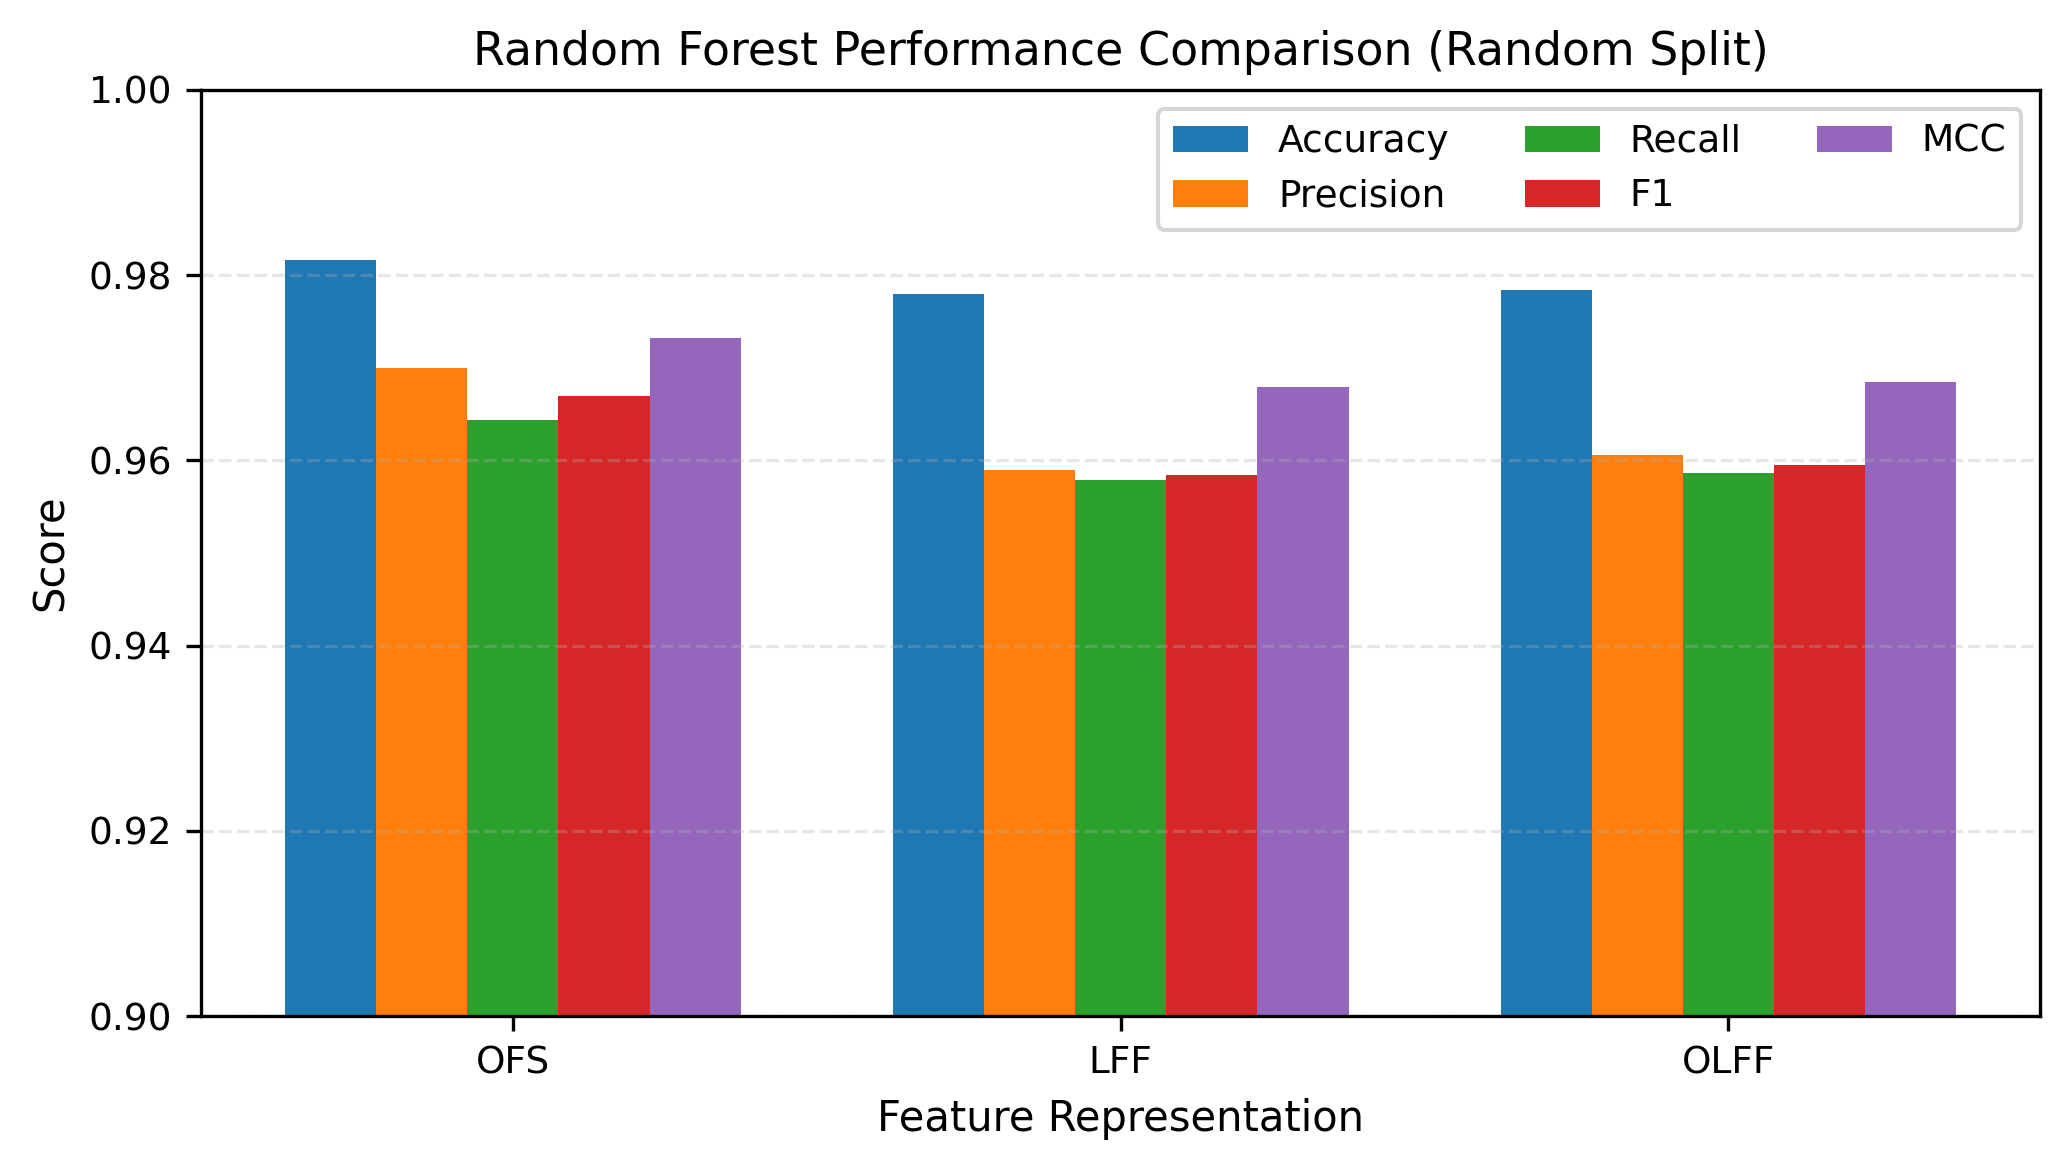

Saved: /content/drive/MyDrive/ROSID/Figure/Random Forest/RF_RandomSplit_Performance.png


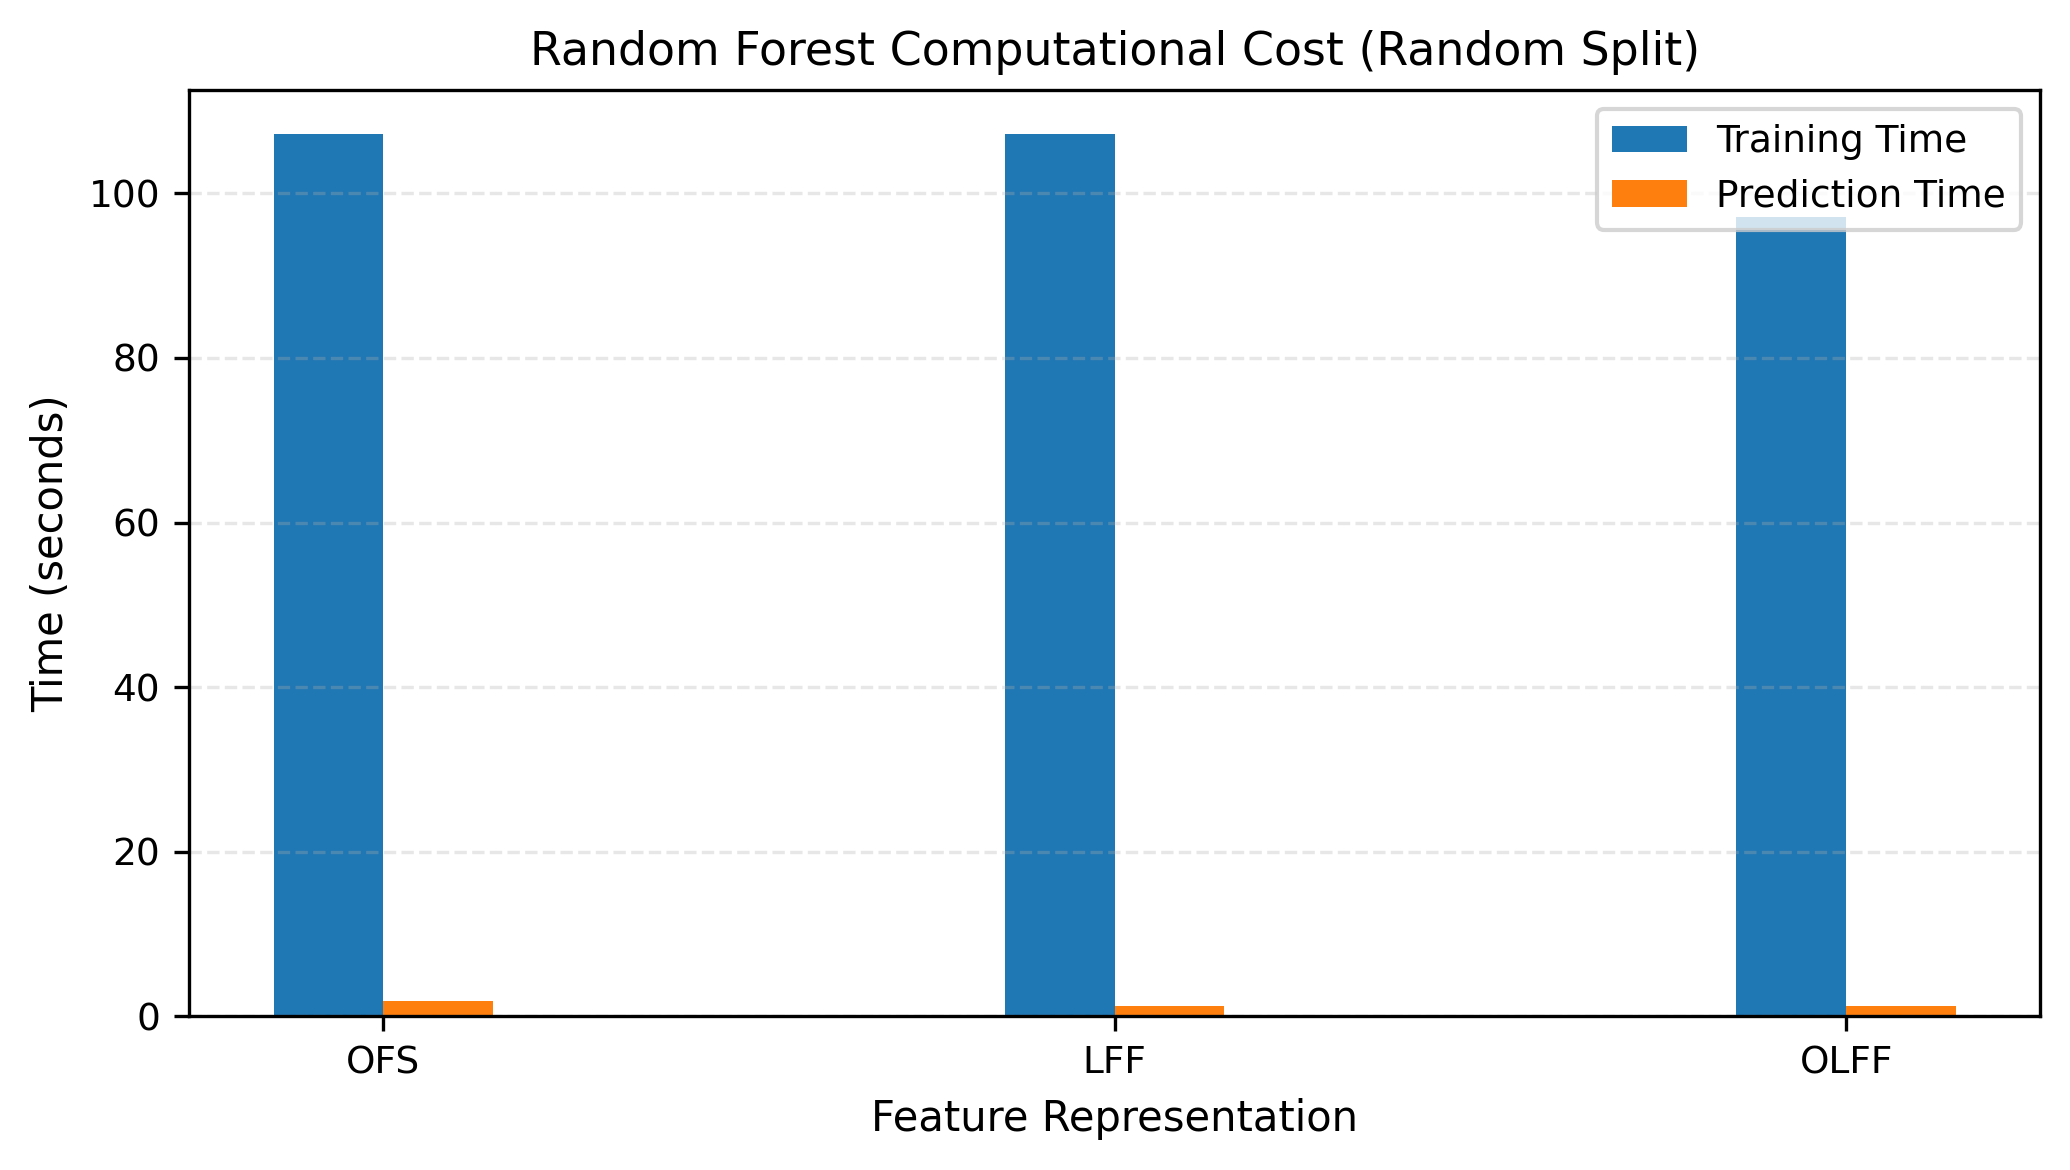

Saved: /content/drive/MyDrive/ROSID/Figure/Random Forest/RF_RandomSplit_Runtime.png


In [7]:
# ============================================================
# BLOCK 4.1
# IEEE Style Visualization
# Random Split RF Results
# ============================================================


# ============================================================
# 1. Prepare Visualization Data
# ============================================================


rf_random_df = random_split_results_df.copy()


print(rf_random_df)



# ============================================================
# 2. Performance Comparison Figure
# ============================================================


metrics = [

    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "MCC"

]


feature_names = (

    rf_random_df["Feature_Set"]
    .tolist()

)



x = np.arange(
    len(feature_names)
)


width = 0.15



fig, ax = plt.subplots(

    figsize=(7,4),

    dpi=300

)



for i, metric in enumerate(metrics):

    values = (

        rf_random_df[metric]
        .values

    )


    ax.bar(

        x + i*width,

        values,

        width,

        label=metric

    )



# Axis formatting

ax.set_xlabel(
    "Feature Representation"
)


ax.set_ylabel(
    "Score"
)


ax.set_title(
    "Random Forest Performance Comparison (Random Split)"
)



ax.set_xticks(

    x + width*2

)


ax.set_xticklabels(

    feature_names

)



ax.set_ylim(

    0.90,

    1.00

)



ax.grid(

    axis="y",

    linestyle="--",

    alpha=0.3

)



ax.legend(

    frameon=True,

    ncol=3

)



plt.tight_layout()



performance_path = os.path.join(

    FIGURE_PATH,

    "RF_RandomSplit_Performance.png"

)



plt.savefig(

    performance_path,

    dpi=600,

    bbox_inches="tight"

)



plt.show()



print(
    "Saved:",
    performance_path
)





# ============================================================
# 3. Runtime Comparison Figure
# ============================================================


runtime_metrics = [

    "Training_Time_sec",

    "Prediction_Time_sec"

]



runtime_labels = [

    "Training Time",

    "Prediction Time"

]



fig, ax = plt.subplots(

    figsize=(7,4),

    dpi=300

)



for i, metric in enumerate(runtime_metrics):


    values = (

        rf_random_df[metric]
        .values

    )


    ax.bar(

        x + i*width,

        values,

        width,

        label=runtime_labels[i]

    )



ax.set_xlabel(

    "Feature Representation"

)



ax.set_ylabel(

    "Time (seconds)"

)



ax.set_title(

    "Random Forest Computational Cost (Random Split)"

)



ax.set_xticks(

    x + width/2

)


ax.set_xticklabels(

    feature_names

)



ax.grid(

    axis="y",

    linestyle="--",

    alpha=0.3

)



ax.legend()



plt.tight_layout()



runtime_path = os.path.join(

    FIGURE_PATH,

    "RF_RandomSplit_Runtime.png"

)



plt.savefig(

    runtime_path,

    dpi=600,

    bbox_inches="tight"

)



plt.show()



print(
    "Saved:",
    runtime_path
)

# **05. RF - Stratified 5-Fold CV**

In [8]:
# ============================================================
# BLOCK 5
# Stratified 5-Fold Cross Validation
# Final Random Forest Experiments
# ============================================================


# Storage

cv_fold_results = []

cv_models = {}



# ============================================================
# Stratified K-Fold Definition
# ============================================================


skf = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=RANDOM_STATE

)



# ============================================================
# Run Experiments
# ============================================================


for name, pipeline in rf_models.items():


    print("\n" + "="*60)
    print("Stratified CV Training:", name)
    print("="*60)


    X_data = feature_sets[name]


    fold_number = 1



    fold_metrics = []



    for train_idx, test_idx in skf.split(
        X_data,
        y
    ):


        print(
            "Fold:",
            fold_number
        )


        X_train = X_data.iloc[train_idx]

        X_test = X_data.iloc[test_idx]


        y_train = y[train_idx]

        y_test = y[test_idx]



        start_time = time.time()



        pipeline.fit(

            X_train,

            y_train

        )


        train_time = (

            time.time()

            -

            start_time

        )



        start_pred = time.time()



        y_pred = pipeline.predict(

            X_test

        )



        pred_time = (

            time.time()

            -

            start_pred

        )



        fold_result = {


            "Feature_Set":

            name,


            "Fold":

            fold_number,


            "Accuracy":

            accuracy_score(

                y_test,

                y_pred

            ),


            "Precision":

            precision_score(

                y_test,

                y_pred,

                average="macro",

                zero_division=0

            ),


            "Recall":

            recall_score(

                y_test,

                y_pred,

                average="macro",

                zero_division=0

            ),


            "F1":

            f1_score(

                y_test,

                y_pred,

                average="macro",

                zero_division=0

            ),


            "MCC":

            matthews_corrcoef(

                y_test,

                y_pred

            ),


            "Training_Time_sec":

            train_time,


            "Prediction_Time_sec":

            pred_time


        }



        cv_fold_results.append(

            fold_result

        )


        fold_metrics.append(

            fold_result

        )


        fold_number += 1



    # ========================================================
    # Train final model on complete dataset
    # ========================================================


    print(
        "Training final model:",
        name
    )


    pipeline.fit(

        X_data,

        y

    )


    cv_models[name] = pipeline



    model_path = os.path.join(

        MODEL_PATH,

        f"RF_{name}_StratifiedCV.pkl"

    )



    joblib.dump(

        pipeline,

        model_path

    )



    print(

        name,

        "saved"

    )



# ============================================================
# Save Fold Results
# ============================================================


cv_fold_df = pd.DataFrame(

    cv_fold_results

)



cv_fold_df.to_csv(

    os.path.join(

        RESULT_PATH,

        "RF_StratifiedCV_Fold_Results.csv"

    ),

    index=False

)



# ============================================================
# Create Summary Table
# ============================================================


cv_summary_df = (


    cv_fold_df

    .groupby(
        "Feature_Set"
    )

    [

        [

        "Accuracy",

        "Precision",

        "Recall",

        "F1",

        "MCC",

        "Training_Time_sec",

        "Prediction_Time_sec"

        ]

    ]

    .agg(

        [
            "mean",

            "std"

        ]

    )


)



cv_summary_df.to_csv(

    os.path.join(

        RESULT_PATH,

        "RF_StratifiedCV_Summary.csv"

    )

)



print("\n========== Stratified CV Completed ==========")


print("\nFold Results:")

display(

    cv_fold_df

)



print("\nSummary:")

display(

    cv_summary_df

)


Stratified CV Training: OFS
Fold: 1
Fold: 2
Fold: 3
Fold: 4
Fold: 5
Training final model: OFS
OFS saved

Stratified CV Training: LFF
Fold: 1
Fold: 2
Fold: 3
Fold: 4
Fold: 5
Training final model: LFF
LFF saved

Stratified CV Training: OLFF
Fold: 1
Fold: 2
Fold: 3
Fold: 4
Fold: 5
Training final model: OLFF
OLFF saved

========== Stratified CV Completed ==========

Fold Results:


,Feature_Set,Fold,Accuracy,Precision,Recall,F1,MCC,Training_Time_sec,Prediction_Time_sec
0,OFS,1,0.981856,0.971359,0.964551,0.967828,0.973539,99.357742,1.019906
1,OFS,2,0.982916,0.971456,0.966822,0.969011,0.975093,98.565502,1.748991
2,OFS,3,0.978892,0.964364,0.958167,0.961201,0.969210,99.086681,1.002733
3,OFS,4,0.982916,0.971077,0.967863,0.969306,0.975102,101.419564,1.032446
4,OFS,5,0.981087,0.970720,0.962545,0.966477,0.972413,105.378846,1.040099
5,LFF,1,0.978674,0.960770,0.959044,0.959872,0.968912,101.282595,1.034195
6,LFF,2,0.979441,0.961537,0.958952,0.960199,0.970026,93.775435,0.875233
7,LFF,3,0.976771,0.955039,0.955989,0.955507,0.966143,96.964939,1.548031
8,LFF,4,0.979148,0.958821,0.960638,0.959659,0.969629,95.640455,0.926990
9,LFF,5,0.978014,0.959273,0.957878,0.958549,0.967953,96.231635,1.593471



Summary:


Accuracy           Precision              Recall            \
                 mean       std      mean       std      mean       std   
Feature_Set                                                               
LFF          0.978410  0.001063  0.959088  0.002516  0.958500  0.001715   
OFS          0.981534  0.001666  0.969795  0.003050  0.963990  0.003851   
OLFF         0.978549  0.001221  0.959718  0.002814  0.958698  0.002345   

                   F1                 MCC           Training_Time_sec  \
                 mean       std      mean       std              mean   
Feature_Set                                                             
LFF          0.958757  0.001920  0.968533  0.001551         96.779012   
OFS          0.966765  0.003304  0.973071  0.002438        100.761667   
OLFF         0.959163  0.002388  0.968733  0.001784         86.030329   

                      Prediction_Time_sec            
                  std                mean       std  
Feature_Set                                          
LFF          2.780928            1.195584  0.347616  
OFS          2.799594            1.168835  0.324625  
OLFF         3.318733            1.061074  0.379071

# **06. RF - Group K-Fold**

In [10]:
# ============================================================
# BLOCK 6
# GroupKFold Session-Level Evaluation
# Final Random Forest Experiments
# ============================================================


# Storage

group_results = []

group_reports = []

group_confusion = []



# ============================================================
# GroupKFold Definition
# ============================================================


gkf = GroupKFold(
    n_splits=3
)



# ============================================================
# Run Experiments
# ============================================================


for name, pipeline in rf_models.items():


    print("\n" + "="*60)
    print("GroupKFold Training:", name)
    print("="*60)



    X_data = feature_sets[name]


    fold = 1



    for train_idx, test_idx in gkf.split(

        X_data,

        y,

        groups

    ):


        print(
            "\nFold:",
            fold
        )


        train_sessions = np.unique(
            groups[train_idx]
        )


        test_sessions = np.unique(
            groups[test_idx]
        )


        print(
            "Train Sessions:",
            train_sessions
        )


        print(
            "Test Session:",
            test_sessions
        )



        X_train = X_data.iloc[train_idx]

        X_test = X_data.iloc[test_idx]


        y_train = y[train_idx]

        y_test = y[test_idx]



        start_time = time.time()



        pipeline.fit(

            X_train,

            y_train

        )



        train_time = (

            time.time()

            -

            start_time

        )



        start_pred = time.time()



        y_pred = pipeline.predict(

            X_test

        )



        pred_time = (

            time.time()

            -

            start_pred

        )



        # Metrics

        result = {


            "Feature_Set":

            name,


            "Fold":

            fold,


            "Train_Sessions":

            ",".join(train_sessions),


            "Test_Session":

            ",".join(test_sessions),


            "Accuracy":

            accuracy_score(

                y_test,

                y_pred

            ),


            "Precision":

            precision_score(

                y_test,

                y_pred,

                average="macro",

                zero_division=0

            ),


            "Recall":

            recall_score(

                y_test,

                y_pred,

                average="macro",

                zero_division=0

            ),


            "F1":

            f1_score(

                y_test,

                y_pred,

                average="macro",

                zero_division=0

            ),


            "MCC":

            matthews_corrcoef(

                y_test,

                y_pred

            ),


            "Training_Time_sec":

            train_time,


            "Prediction_Time_sec":

            pred_time

        }



        group_results.append(

            result

        )



        # Classification report

        report = classification_report(

    y_test,

    y_pred,

    labels=np.arange(
        len(label_encoder.classes_)
    ),

    target_names=label_encoder.classes_,

    output_dict=True,

    zero_division=0

)



        for cls, values in report.items():

            if isinstance(values, dict):

                group_reports.append(

                    {

                        "Feature_Set":name,

                        "Fold":fold,

                        "Class":cls,

                        **values

                    }

                )



        # Confusion matrix

        cm = confusion_matrix(

    y_test,

    y_pred,

    labels=np.arange(
        len(label_encoder.classes_)
    )

)



        for i,row in enumerate(cm):

            group_confusion.append(

                {

                    "Feature_Set":name,

                    "Fold":fold,

                    "Actual_Class":
                    label_encoder.classes_[i],

                    "Prediction":
                    row.tolist()

                }

            )



        # Save fold model

        model_file = os.path.join(

            MODEL_PATH,

            f"RF_{name}_GroupKFold_Fold{fold}.pkl"

        )


        joblib.dump(

            pipeline,

            model_file

        )



        fold += 1



# ============================================================
# Save Results
# ============================================================


group_results_df = pd.DataFrame(

    group_results

)



group_results_df.to_csv(

    os.path.join(

        RESULT_PATH,

        "RF_GroupKFold_Fold_Results.csv"

    ),

    index=False

)



pd.DataFrame(

    group_reports

).to_csv(

    os.path.join(

        RESULT_PATH,

        "RF_GroupKFold_Classification_Report.csv"

    ),

    index=False

)



pd.DataFrame(

    group_confusion

).to_csv(

    os.path.join(

        RESULT_PATH,

        "RF_GroupKFold_Confusion_Matrix.csv"

    ),

    index=False

)



print("\n========== GroupKFold Completed ==========")


display(

    group_results_df

)


GroupKFold Training: OFS

Fold: 1
Train Sessions: ['2023-07-07' '2023-08-15']
Test Session: ['2023-07-12']

Fold: 2
Train Sessions: ['2023-07-07' '2023-07-12']
Test Session: ['2023-08-15']

Fold: 3
Train Sessions: ['2023-07-12' '2023-08-15']
Test Session: ['2023-07-07']

GroupKFold Training: LFF

Fold: 1
Train Sessions: ['2023-07-07' '2023-08-15']
Test Session: ['2023-07-12']

Fold: 2
Train Sessions: ['2023-07-07' '2023-07-12']
Test Session: ['2023-08-15']

Fold: 3
Train Sessions: ['2023-07-12' '2023-08-15']
Test Session: ['2023-07-07']

GroupKFold Training: OLFF

Fold: 1
Train Sessions: ['2023-07-07' '2023-08-15']
Test Session: ['2023-07-12']

Fold: 2
Train Sessions: ['2023-07-07' '2023-07-12']
Test Session: ['2023-08-15']

Fold: 3
Train Sessions: ['2023-07-12' '2023-08-15']
Test Session: ['2023-07-07']

========== GroupKFold Completed ==========


,Feature_Set,Fold,Train_Sessions,Test_Session,Accuracy,Precision,Recall,F1,MCC,Training_Time_sec,Prediction_Time_sec
0,OFS,1,"2023-07-07,2023-08-15",2023-07-12,0.347566,0.075002,0.194349,0.108235,0.054138,54.485658,1.658509
1,OFS,2,"2023-07-07,2023-07-12",2023-08-15,0.342110,0.110331,0.241034,0.151373,0.167496,78.841981,1.226570
2,OFS,3,"2023-07-12,2023-08-15",2023-07-07,0.913896,0.250000,0.228474,0.238753,0.000000,103.617059,0.944205
3,LFF,1,"2023-07-07,2023-08-15",2023-07-12,0.347756,0.074530,0.194454,0.107758,0.049117,56.003479,1.842031
4,LFF,2,"2023-07-07,2023-07-12",2023-08-15,0.344170,0.079611,0.193989,0.112892,0.112738,77.315305,1.344515
5,LFF,3,"2023-07-12,2023-08-15",2023-07-07,0.899094,0.250000,0.224774,0.236717,0.000000,99.802761,0.895745
6,OLFF,1,"2023-07-07,2023-08-15",2023-07-12,0.347537,0.074573,0.194332,0.107784,0.049376,44.926879,1.478651
7,OLFF,2,"2023-07-07,2023-07-12",2023-08-15,0.345415,0.101304,0.243363,0.143058,0.124675,64.017206,1.257998
8,OLFF,3,"2023-07-12,2023-08-15",2023-07-07,0.903250,0.250000,0.225812,0.237291,0.000000,88.381281,0.910215


# **07. Random Forest Final Comparison**

,Feature_Set,Evaluation,Accuracy,Precision,Recall,F1,MCC
0,OFS,Random Split,0.981600,0.969930,0.964327,0.966943,0.973174
1,LFF,Random Split,0.977979,0.959014,0.957885,0.958383,0.967909
2,OLFF,Random Split,0.978381,0.960593,0.958675,0.959562,0.968491
3,LFF,Stratified CV,0.978410,0.959088,0.958500,0.958757,0.968533
4,OFS,Stratified CV,0.981534,0.969795,0.963990,0.966765,0.973071
5,OLFF,Stratified CV,0.978549,0.959718,0.958698,0.959163,0.968733
6,LFF,GroupKFold,0.530340,0.134714,0.204405,0.152456,0.053952
7,OFS,GroupKFold,0.534524,0.145111,0.221286,0.166120,0.073878
8,OLFF,GroupKFold,0.532067,0.141959,0.221169,0.162711,0.058017


,Feature_Set,Number_of_Features,Reduction_Percentage
0,OFS,82,0.000000
1,LFF,65,20.731707
2,OLFF,43,47.560976


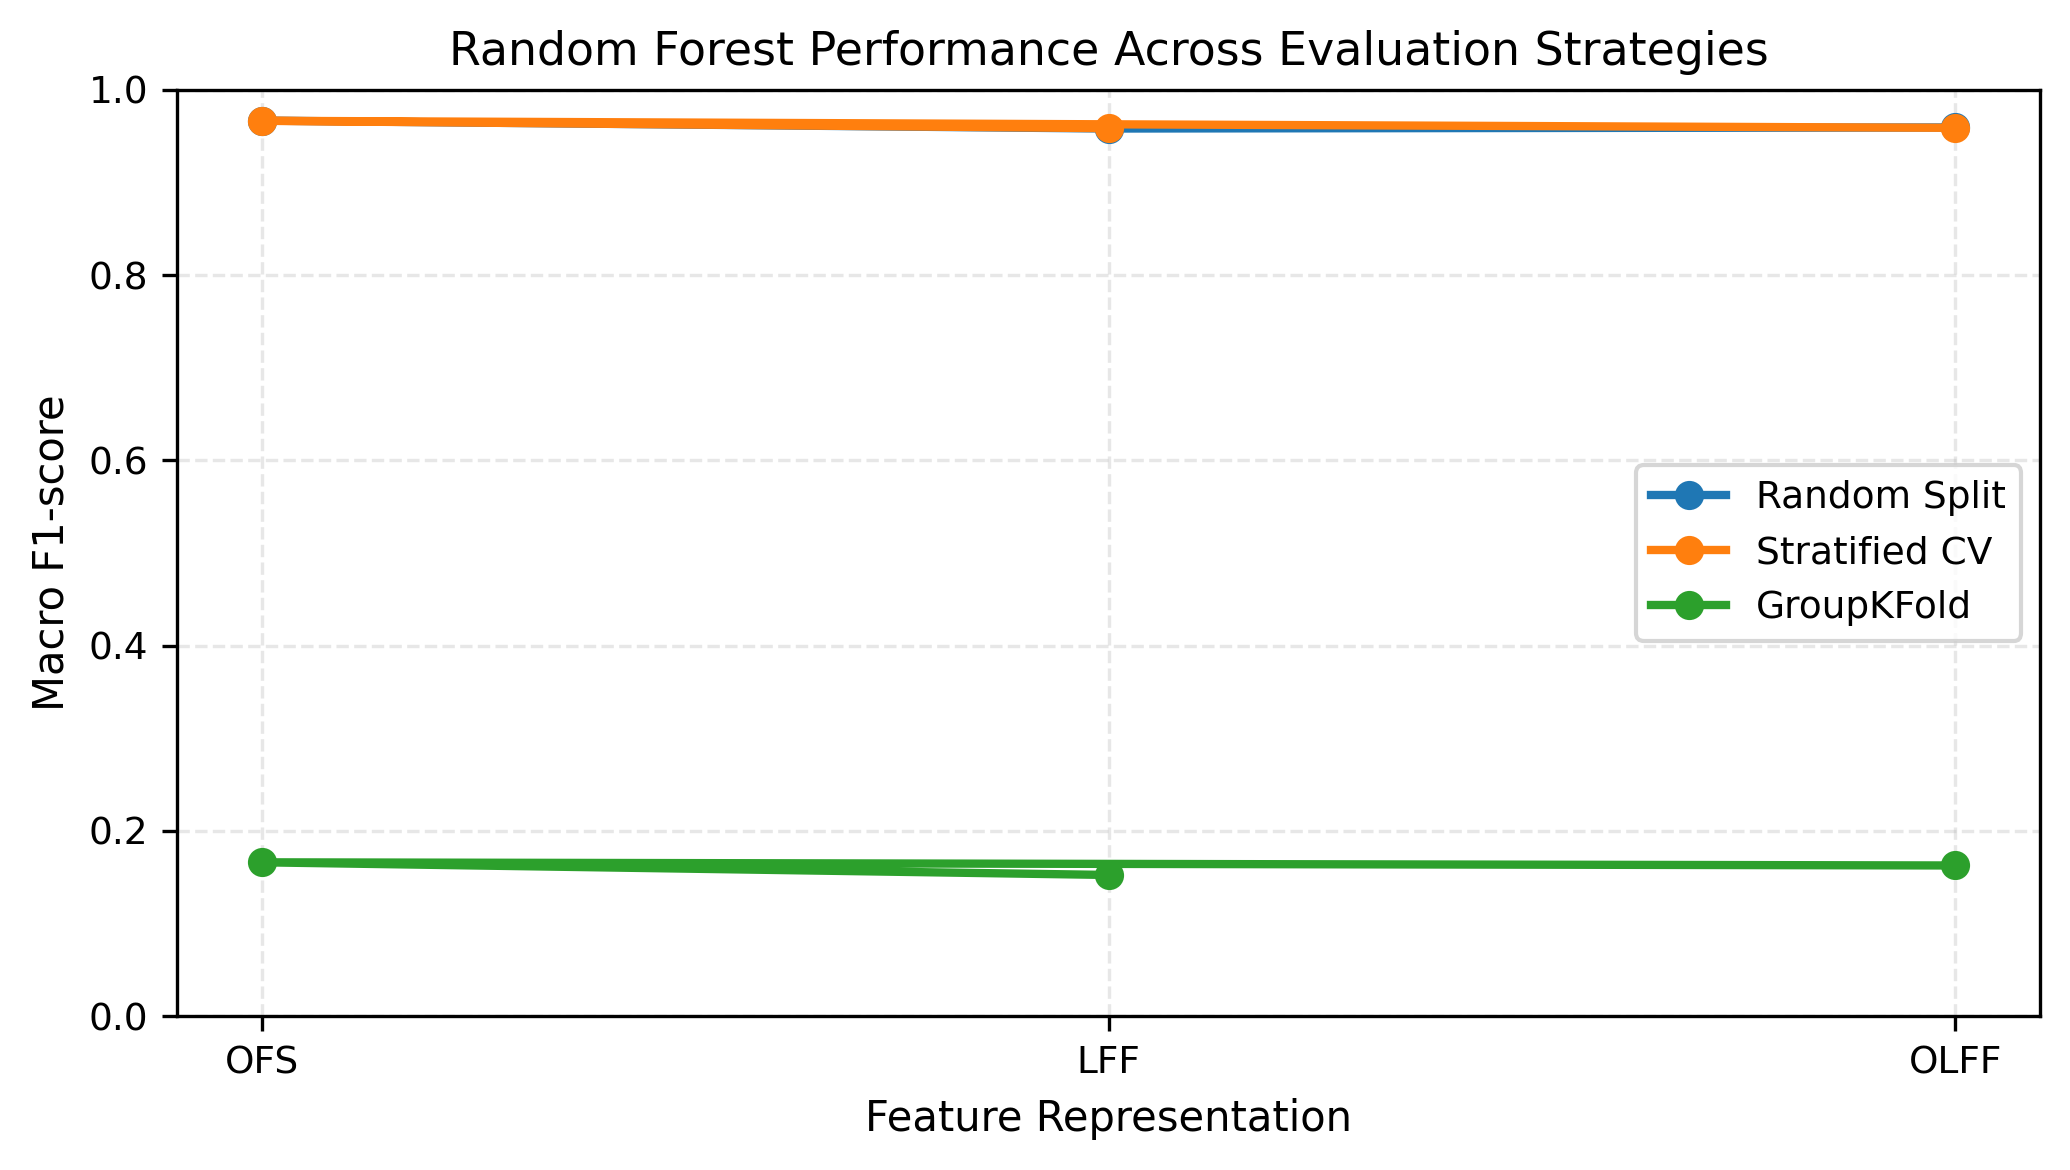

RF Final Comparison Package Completed


In [11]:
# ============================================================
# BLOCK 7
# Final RF Comparison Package
# IEEE Paper Preparation
# ============================================================


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os



# ============================================================
# 1. Load Existing Results
# ============================================================


random_df = pd.read_csv(

    os.path.join(
        RESULT_PATH,
        "RF_RandomSplit_Results.csv"
    )

)



cv_df = pd.read_csv(

    os.path.join(
        RESULT_PATH,
        "RF_StratifiedCV_Fold_Results.csv"
    )

)



group_df = pd.read_csv(

    os.path.join(
        RESULT_PATH,
        "RF_GroupKFold_Fold_Results.csv"
    )

)



# ============================================================
# 2. Create Summary Tables
# ============================================================


final_results = []



# Random Split

for _,row in random_df.iterrows():

    final_results.append({

        "Feature_Set":row["Feature_Set"],

        "Evaluation":
        "Random Split",

        "Accuracy":
        row["Accuracy"],

        "Precision":
        row["Precision"],

        "Recall":
        row["Recall"],

        "F1":
        row["F1"],

        "MCC":
        row["MCC"]

    })



# Stratified CV

cv_summary = (

    cv_df
    .groupby("Feature_Set")
    [
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "MCC"
        ]
    ]
    .mean()
    .reset_index()

)



for _,row in cv_summary.iterrows():

    final_results.append({

        "Feature_Set":row["Feature_Set"],

        "Evaluation":
        "Stratified CV",

        "Accuracy":
        row["Accuracy"],

        "Precision":
        row["Precision"],

        "Recall":
        row["Recall"],

        "F1":
        row["F1"],

        "MCC":
        row["MCC"]

    })



# GroupKFold

group_summary = (

    group_df
    .groupby("Feature_Set")
    [
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "MCC"
        ]
    ]
    .mean()
    .reset_index()

)



for _,row in group_summary.iterrows():

    final_results.append({

        "Feature_Set":row["Feature_Set"],

        "Evaluation":
        "GroupKFold",

        "Accuracy":
        row["Accuracy"],

        "Precision":
        row["Precision"],

        "Recall":
        row["Recall"],

        "F1":
        row["F1"],

        "MCC":
        row["MCC"]

    })



final_df = pd.DataFrame(final_results)



final_df.to_csv(

    os.path.join(
        RESULT_PATH,
        "RF_Final_Performance_Comparison.csv"
    ),

    index=False

)



display(final_df)



# ============================================================
# 3. Feature Reduction Table
# ============================================================


feature_df = pd.DataFrame({

    "Feature_Set":
    [
        "OFS",
        "LFF",
        "OLFF"
    ],

    "Number_of_Features":
    [
        82,
        65,
        43
    ]

})


feature_df["Reduction_Percentage"] = [

    0,

    ((82-65)/82)*100,

    ((82-43)/82)*100

]



feature_df.to_csv(

    os.path.join(
        RESULT_PATH,
        "RF_Feature_Reduction.csv"
    ),

    index=False

)



display(feature_df)



# ============================================================
# 4. IEEE Performance Figure
# ============================================================


plt.figure(

    figsize=(7,4)

)



for evaluation in final_df["Evaluation"].unique():

    temp = final_df[
        final_df["Evaluation"]==evaluation
    ]

    plt.plot(

        temp["Feature_Set"],

        temp["F1"],

        marker="o",

        linewidth=2,

        label=evaluation

    )



plt.ylabel(
    "Macro F1-score"
)


plt.xlabel(
    "Feature Representation"
)


plt.title(
    "Random Forest Performance Across Evaluation Strategies"
)


plt.ylim(
    0,
    1
)


plt.grid(
    linestyle="--",
    alpha=0.3
)


plt.legend()



plt.tight_layout()



plt.savefig(

    os.path.join(

        FIGURE_PATH,

        "RF_Performance_All_Strategies.png"

    ),

    dpi=600,

    bbox_inches="tight"

)



plt.show()



print("RF Final Comparison Package Completed")

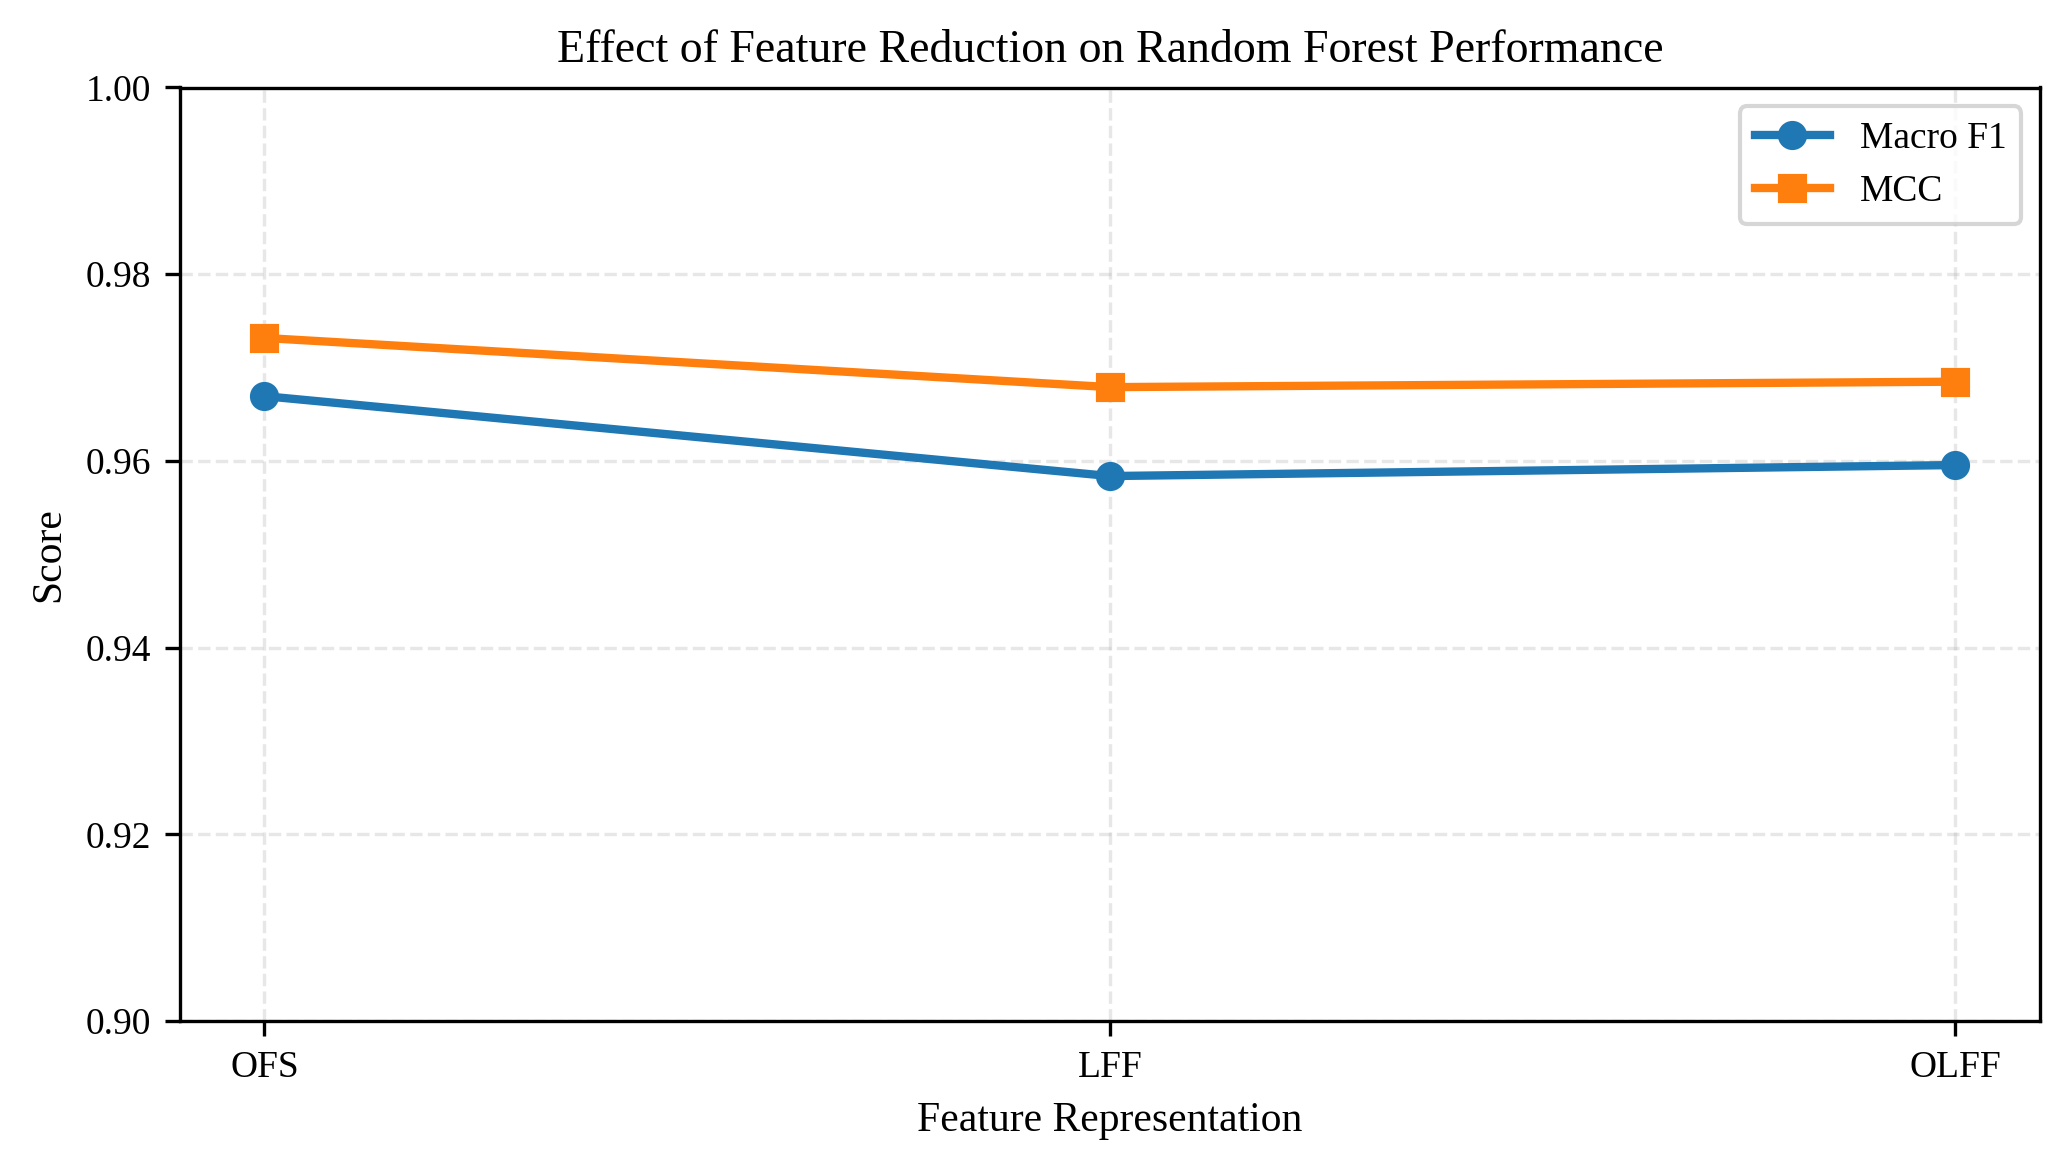

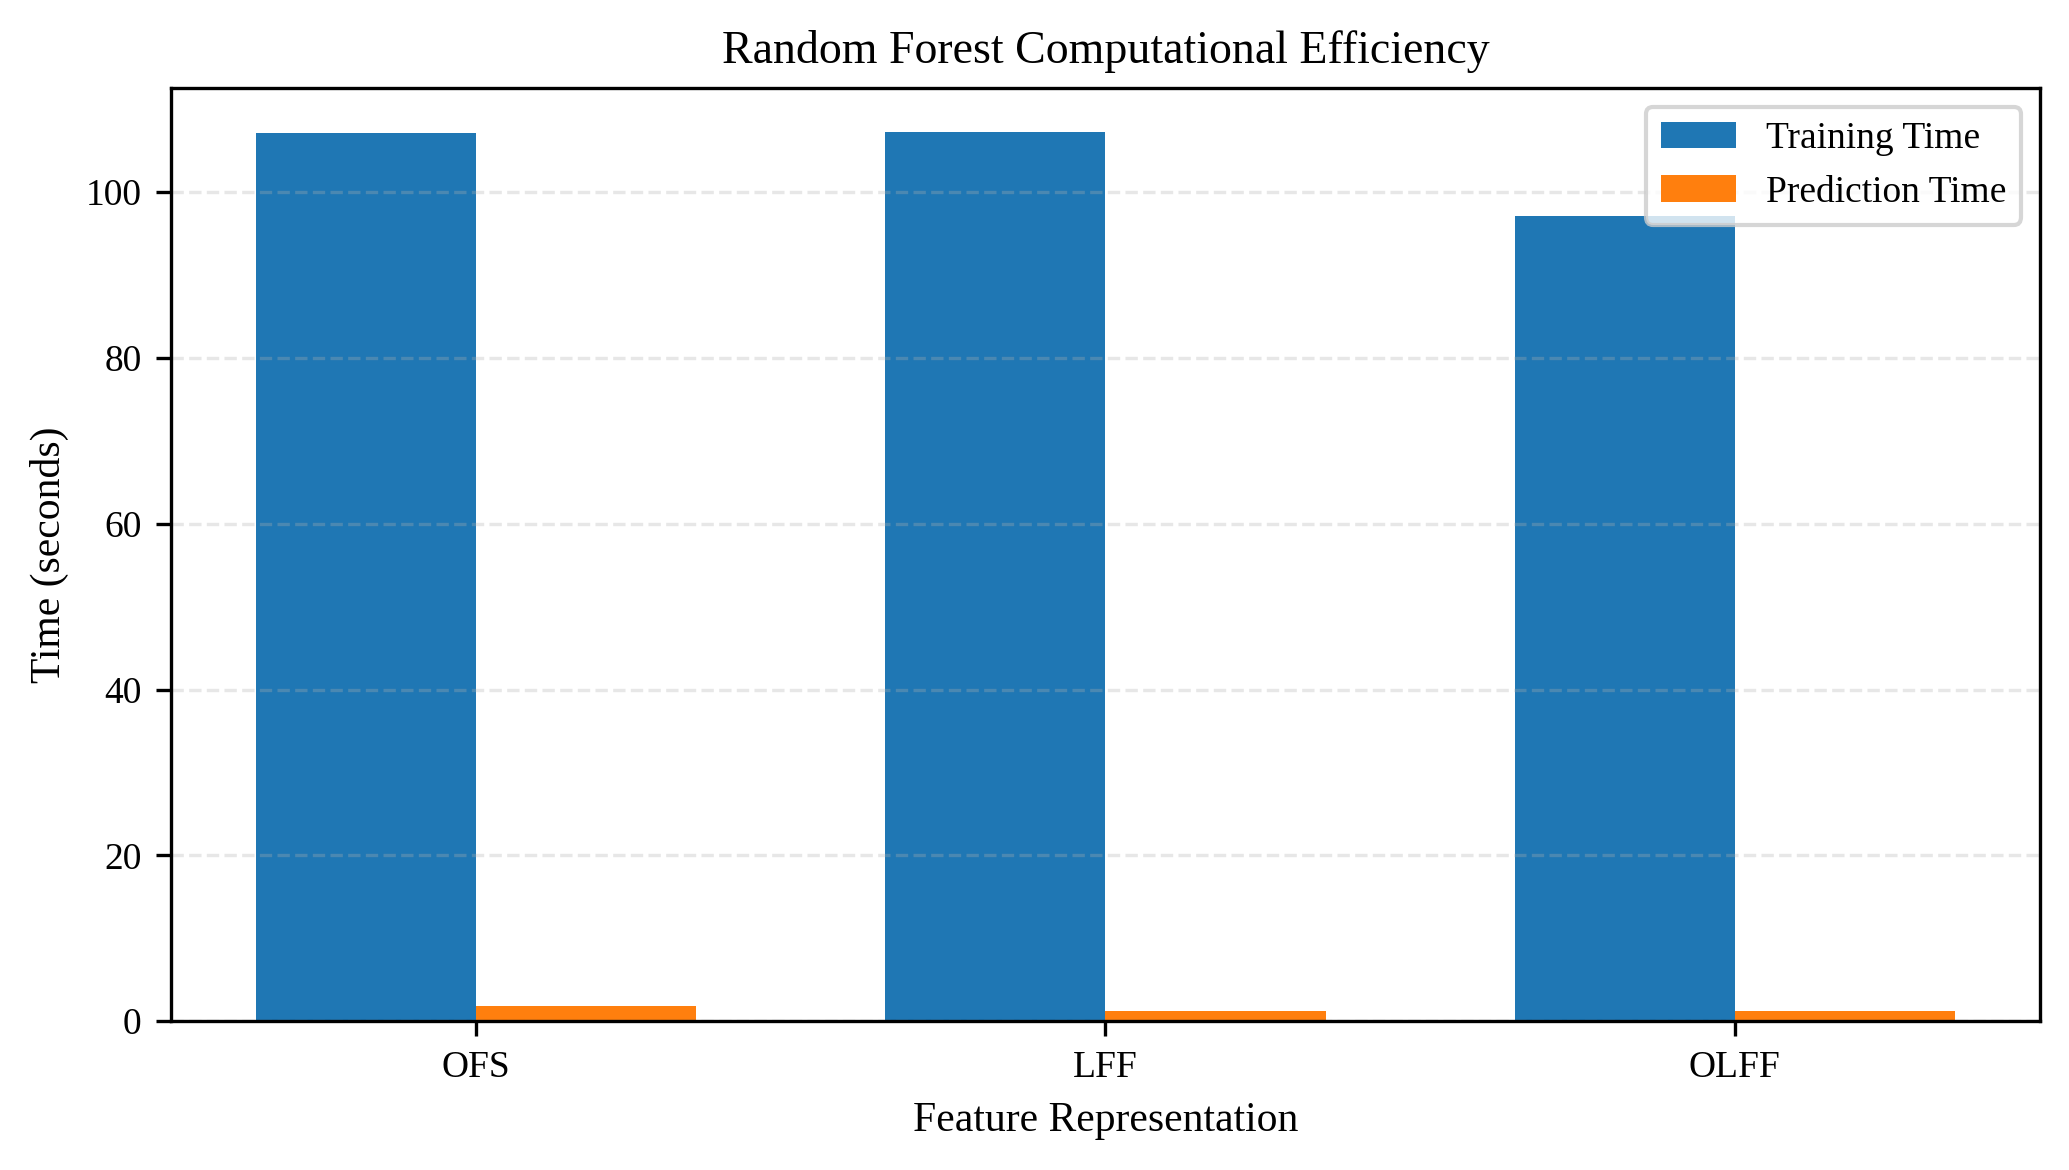

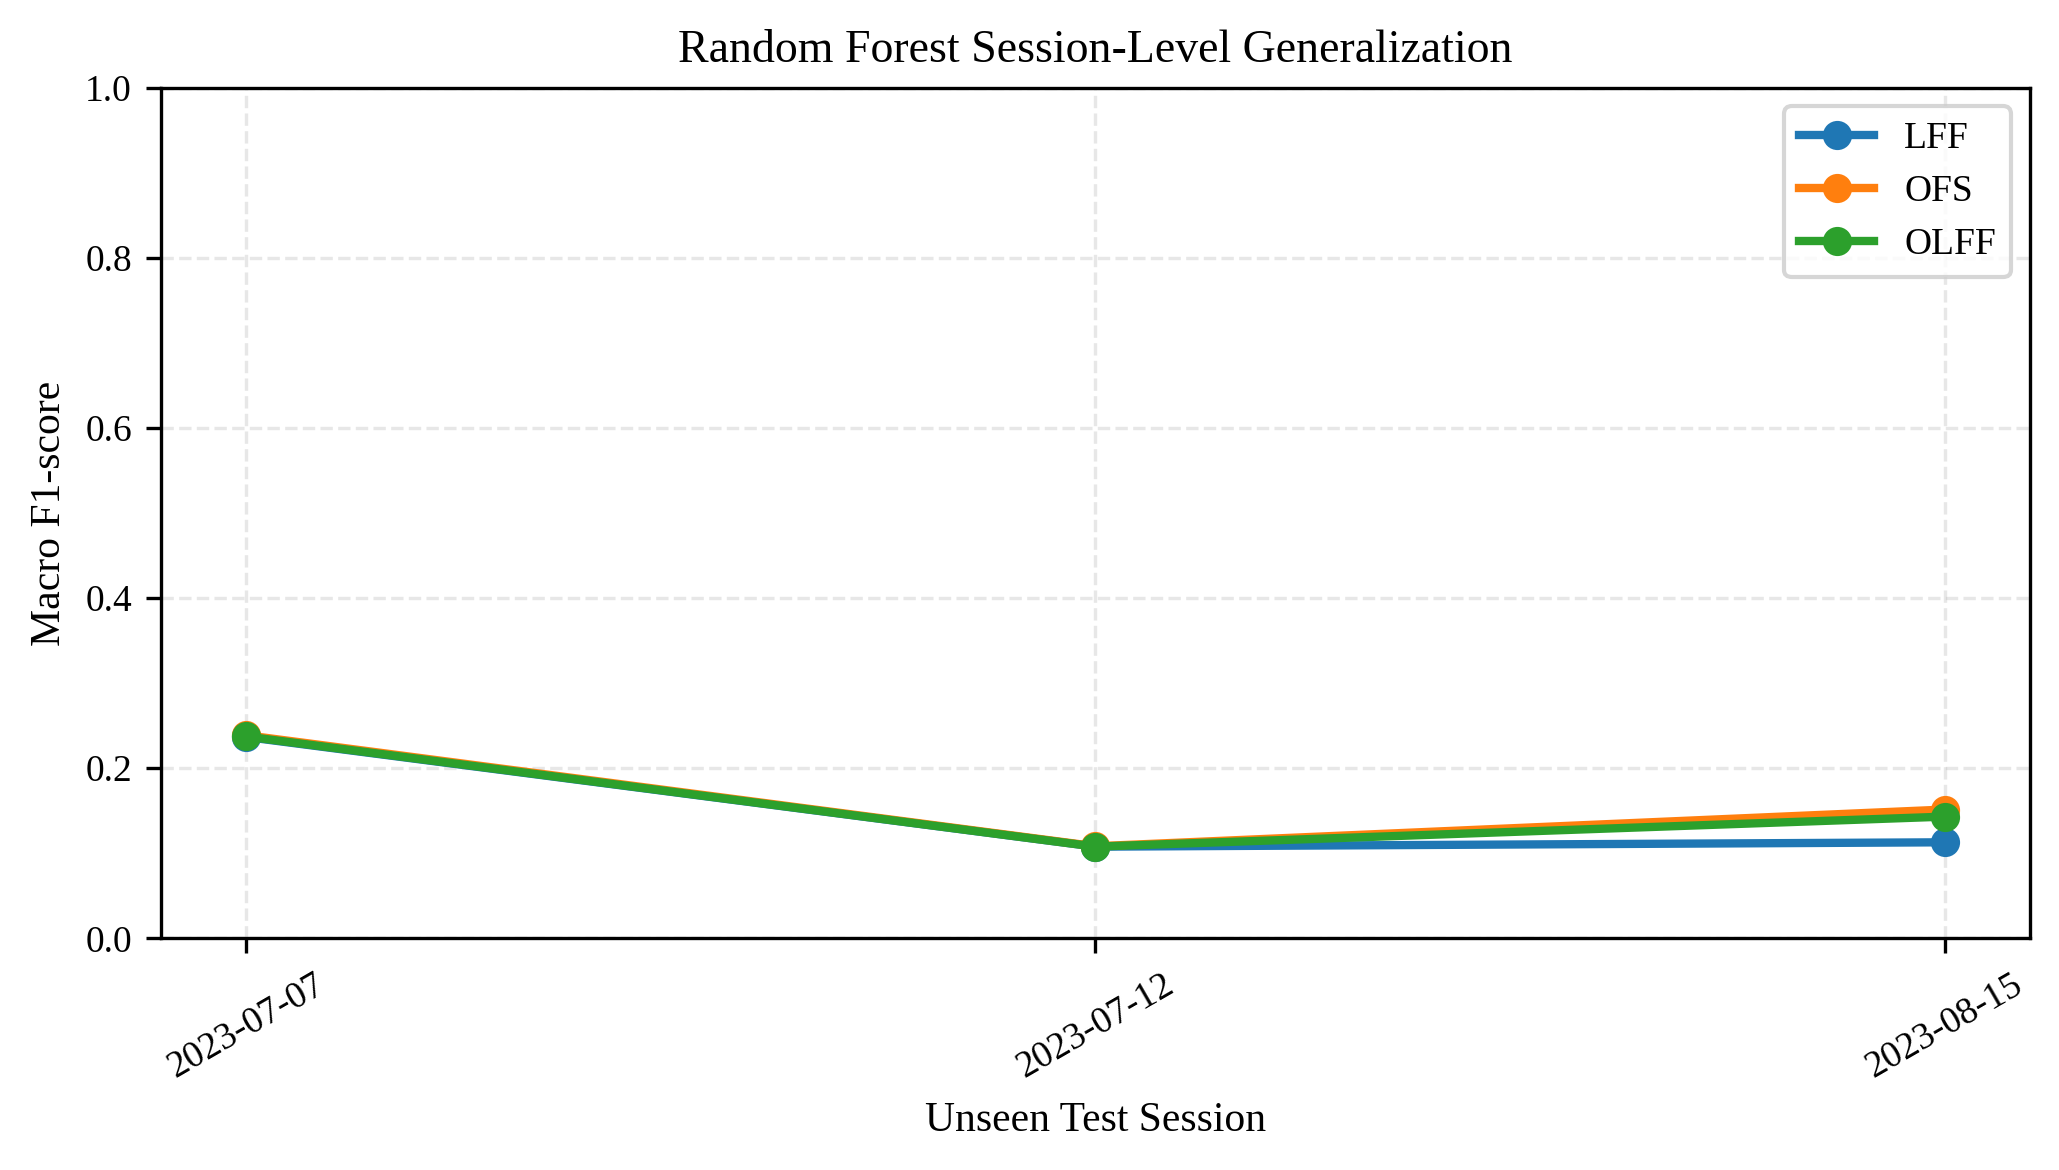

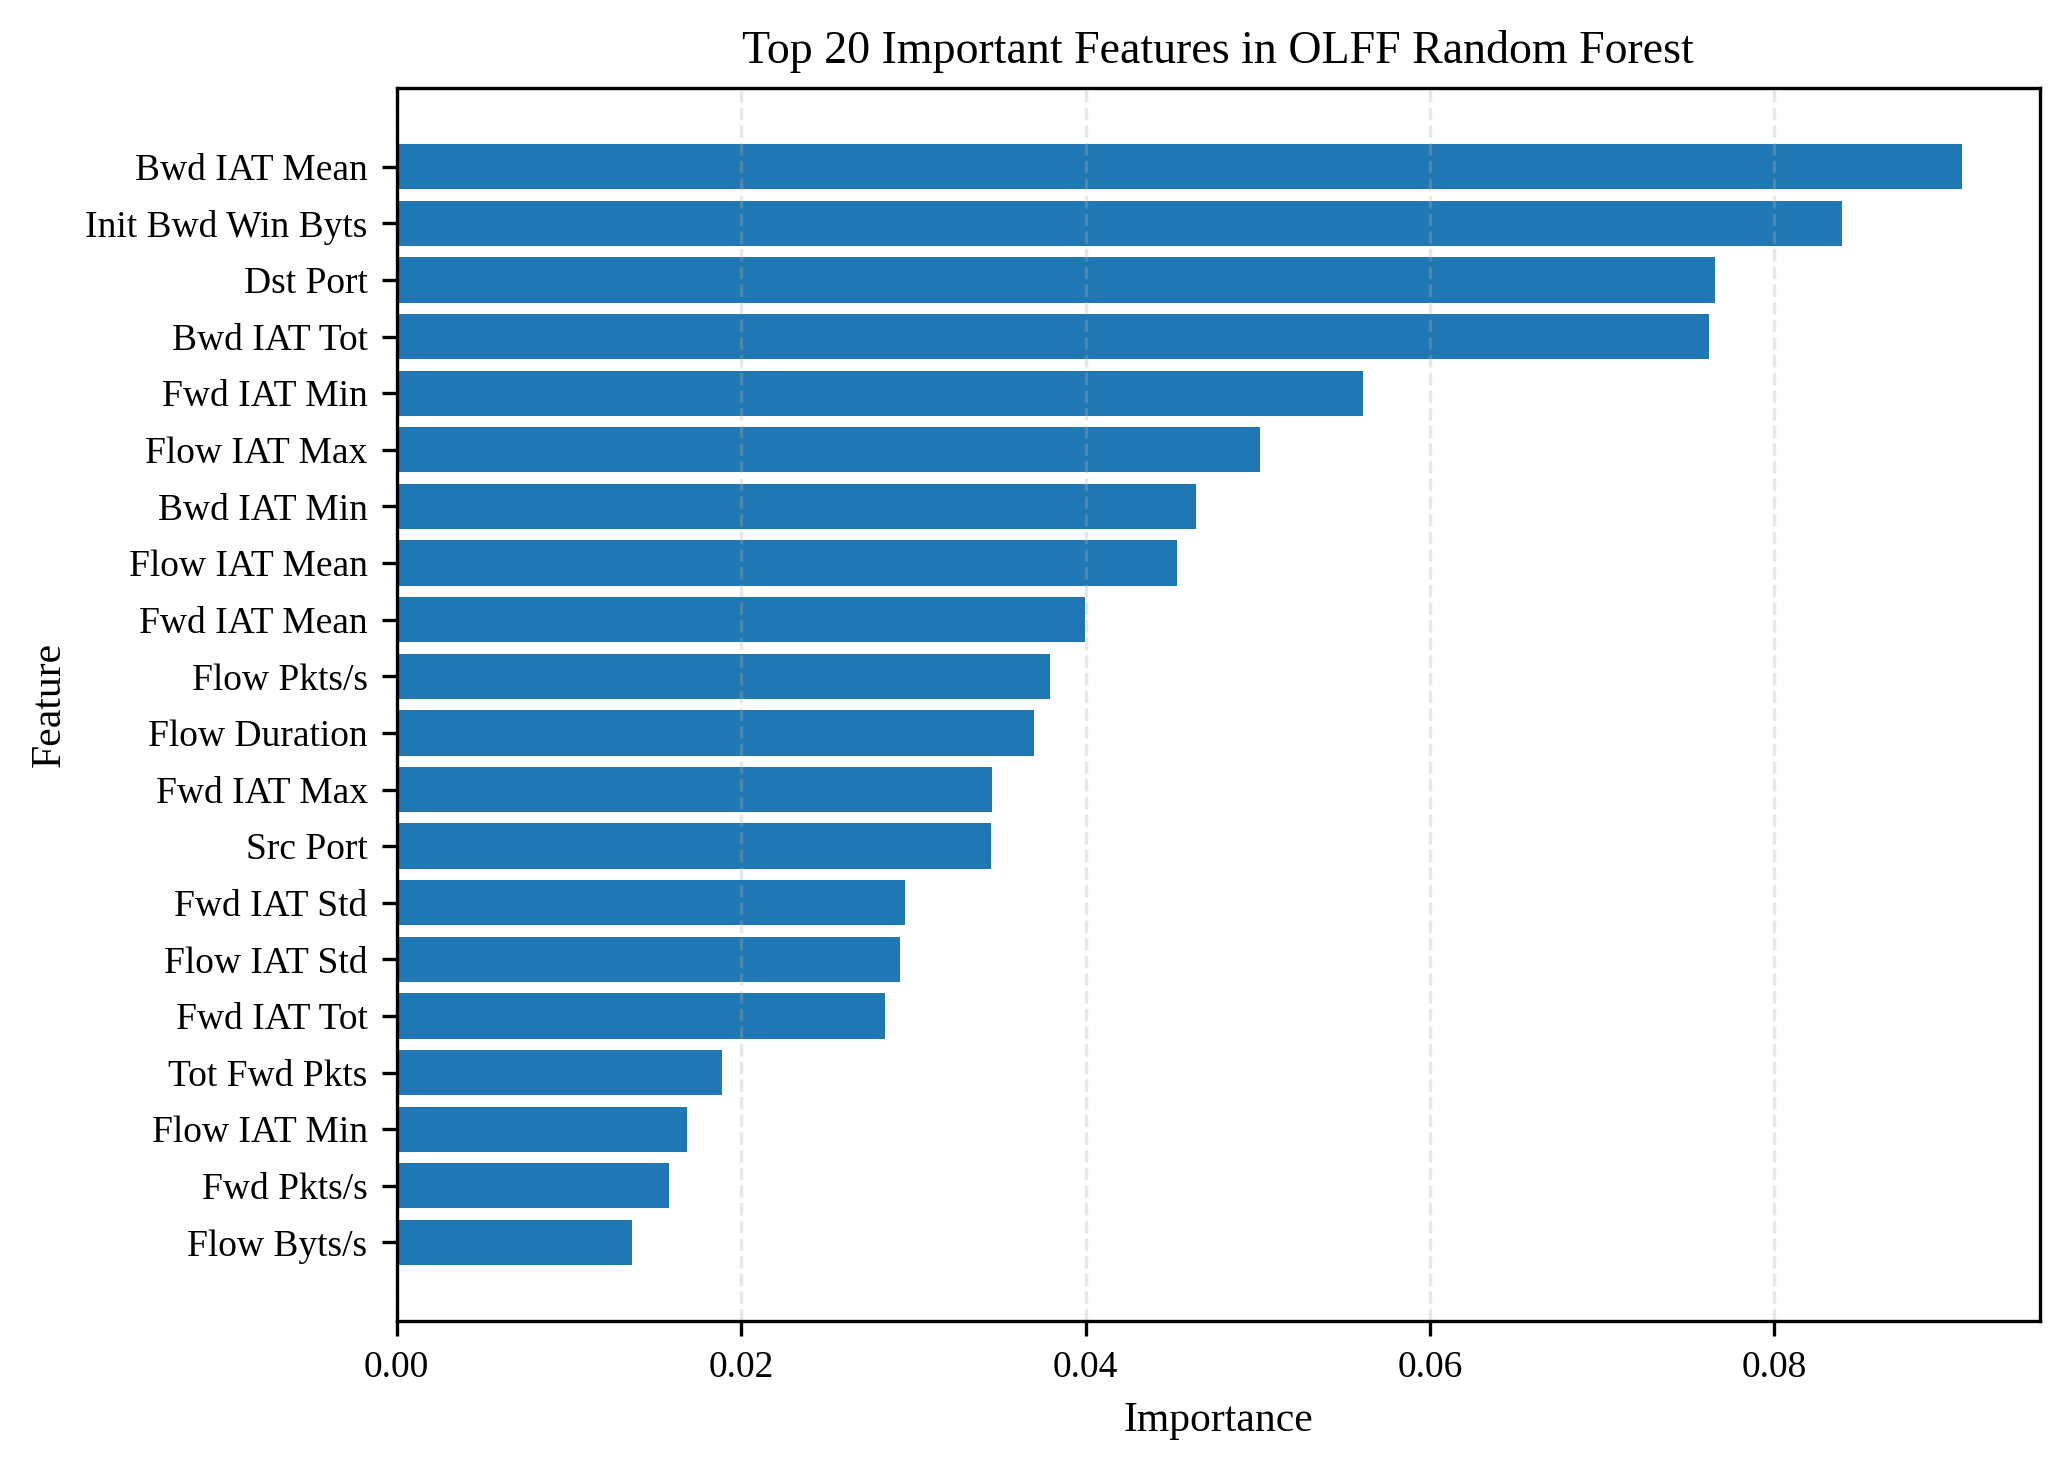

RF IEEE Figure Package Completed


In [12]:
# ============================================================
# BLOCK 7.1
# Complete RF IEEE Figure Generation
# ============================================================


import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os



# ============================================================
# IEEE-Compatible Font
# ============================================================

plt.rcParams.update({

    "font.family": "Liberation Serif",

    "font.size": 10,

    "axes.labelsize": 10,

    "axes.titlesize": 11,

    "xtick.labelsize": 9,

    "ytick.labelsize": 9,

    "legend.fontsize": 9

})



# ============================================================
# Figure 1
# Feature Reduction vs Performance
# ============================================================


feature_performance = pd.DataFrame({

    "Feature_Set":
    [
        "OFS",
        "LFF",
        "OLFF"
    ],

    "Features":
    [
        82,
        65,
        43
    ],

    "F1":
    [
        random_split_results_df.loc[
            random_split_results_df.Feature_Set=="OFS",
            "F1"
        ].values[0],

        random_split_results_df.loc[
            random_split_results_df.Feature_Set=="LFF",
            "F1"
        ].values[0],

        random_split_results_df.loc[
            random_split_results_df.Feature_Set=="OLFF",
            "F1"
        ].values[0]
    ],

    "MCC":
    [
        random_split_results_df.loc[
            random_split_results_df.Feature_Set=="OFS",
            "MCC"
        ].values[0],

        random_split_results_df.loc[
            random_split_results_df.Feature_Set=="LFF",
            "MCC"
        ].values[0],

        random_split_results_df.loc[
            random_split_results_df.Feature_Set=="OLFF",
            "MCC"
        ].values[0]
    ]

})



fig, ax1 = plt.subplots(

    figsize=(7,4)

)


x = np.arange(
    len(feature_performance)
)



ax1.plot(

    x,

    feature_performance["F1"],

    marker="o",

    linewidth=2,

    label="Macro F1"

)


ax1.plot(

    x,

    feature_performance["MCC"],

    marker="s",

    linewidth=2,

    label="MCC"

)



ax1.set_xticks(x)

ax1.set_xticklabels(
    feature_performance["Feature_Set"]
)


ax1.set_xlabel(
    "Feature Representation"
)


ax1.set_ylabel(
    "Score"
)


ax1.set_title(
    "Effect of Feature Reduction on Random Forest Performance"
)


ax1.set_ylim(
    0.90,
    1.00
)


ax1.grid(
    linestyle="--",
    alpha=0.3
)


ax1.legend()



plt.tight_layout()


plt.savefig(

    os.path.join(

        FIGURE_PATH,

        "RF_Feature_Reduction_Performance.png"

    ),

    dpi=600,

    bbox_inches="tight"

)


plt.show()





# ============================================================
# Figure 2
# Runtime Efficiency
# ============================================================


runtime_df = random_split_results_df.copy()



fig, ax = plt.subplots(

    figsize=(7,4)

)



x = np.arange(
    len(runtime_df)
)


width = 0.35



ax.bar(

    x-width/2,

    runtime_df["Training_Time_sec"],

    width,

    label="Training Time"

)



ax.bar(

    x+width/2,

    runtime_df["Prediction_Time_sec"],

    width,

    label="Prediction Time"

)



ax.set_xticks(x)


ax.set_xticklabels(
    runtime_df["Feature_Set"]
)


ax.set_xlabel(
    "Feature Representation"
)


ax.set_ylabel(
    "Time (seconds)"
)


ax.set_title(
    "Random Forest Computational Efficiency"
)


ax.grid(

    axis="y",

    linestyle="--",

    alpha=0.3

)


ax.legend()



plt.tight_layout()


plt.savefig(

    os.path.join(

        FIGURE_PATH,

        "RF_Runtime_Efficiency.png"

    ),

    dpi=600,

    bbox_inches="tight"

)


plt.show()





# ============================================================
# Figure 3
# GroupKFold Generalization
# ============================================================


group_plot = (

    group_results_df

    .groupby(
        [
            "Feature_Set",
            "Test_Session"
        ]
    )

    ["F1"]

    .mean()

    .reset_index()

)



fig, ax = plt.subplots(

    figsize=(7,4)

)



for feature in group_plot.Feature_Set.unique():

    temp = group_plot[
        group_plot.Feature_Set==feature
    ]


    ax.plot(

        temp.Test_Session,

        temp.F1,

        marker="o",

        linewidth=2,

        label=feature

    )



ax.set_xlabel(
    "Unseen Test Session"
)


ax.set_ylabel(
    "Macro F1-score"
)


ax.set_title(
    "Random Forest Session-Level Generalization"
)


ax.set_ylim(
    0,
    1
)


ax.grid(

    linestyle="--",

    alpha=0.3

)


ax.legend()



plt.xticks(
    rotation=30
)


plt.tight_layout()



plt.savefig(

    os.path.join(

        FIGURE_PATH,

        "RF_GroupKFold_Generalization.png"

    ),

    dpi=600,

    bbox_inches="tight"

)


plt.show()





# ============================================================
# Figure 4
# OLFF Feature Importance
# ============================================================


# Load final OLFF Random Split model

olff_model_path = os.path.join(

    MODEL_PATH,

    "RF_OLFF_RandomSplit.pkl"

)


olff_model = joblib.load(

    olff_model_path

)



rf_estimator = (

    olff_model
    .named_steps["classifier"]

)



importance_df = pd.DataFrame({

    "Feature":

    X_olff.columns,


    "Importance":

    rf_estimator.feature_importances_

})



importance_df = (

    importance_df

    .sort_values(

        "Importance",

        ascending=False

    )

    .head(20)

)



importance_df.to_csv(

    os.path.join(

        RESULT_PATH,

        "RF_OLFF_Feature_Importance.csv"

    ),

    index=False

)



fig, ax = plt.subplots(

    figsize=(7,5)

)



ax.barh(

    importance_df["Feature"],

    importance_df["Importance"]

)



ax.invert_yaxis()



ax.set_xlabel(
    "Importance"
)


ax.set_ylabel(
    "Feature"
)


ax.set_title(
    "Top 20 Important Features in OLFF Random Forest"
)


ax.grid(

    axis="x",

    linestyle="--",

    alpha=0.3

)



plt.tight_layout()



plt.savefig(

    os.path.join(

        FIGURE_PATH,

        "RF_OLFF_Feature_Importance.png"

    ),

    dpi=600,

    bbox_inches="tight"

)


plt.show()



print("===================================")

print("RF IEEE Figure Package Completed")

print("===================================")

# **08. Random Forest Model Discussions**

## A. Random Forest Performance Evaluation

The Random Forest (RF) classifier was evaluated using three feature representations: the Original Feature Set (OFS), Leakage-Free Feature Set (LFF), and Optimized Leakage-Free Feature Set (OLFF). The evaluation was conducted under three different validation strategies: random stratified train-test split, stratified five-fold cross-validation, and session-level GroupKFold evaluation. This multi-level evaluation framework was designed to assess both conventional classification performance and the ability of the model to generalize to unseen traffic sessions.

### 1) Performance under Random Stratified Split

The random split evaluation demonstrated strong classification performance across all feature representations. The OFS achieved the highest performance with an accuracy of 98.16%, macro F1-score of 96.69%, and Matthews correlation coefficient (MCC) of 97.32%. After removing potentially leakage-related attributes, the LFF representation achieved 97.80% accuracy, 95.84% macro F1-score, and 96.79% MCC.

The optimized leakage-free representation (OLFF) further reduced the dimensionality while maintaining comparable predictive capability. With only 43 features, OLFF achieved 97.84% accuracy, 95.96% macro F1-score, and 96.85% MCC. Compared with LFF, OLFF produced a slight improvement in all major evaluation metrics, indicating that removing highly correlated features eliminated redundant information without significantly affecting the discriminative capability of the model.

The results demonstrate that the leakage removal process introduced only a limited performance reduction. The feature reduction from OFS (82 features) to OLFF (43 features) resulted in a 47.6% reduction in feature dimensionality while maintaining approximately similar classification performance.

### 2) Stratified Five-Fold Cross-Validation Analysis

To evaluate model stability, stratified five-fold cross-validation was performed. The results were consistent with the random split evaluation, confirming that the RF classifier performance was not dependent on a specific train-test partition.

The OFS representation achieved the highest cross-validation performance with a mean accuracy of 98.15%, macro F1-score of 96.68%, and MCC of 97.31%. The LFF representation achieved 97.84% accuracy, 95.88% macro F1-score, and 96.85% MCC. Meanwhile, OLFF achieved 97.85% accuracy, 95.92% macro F1-score, and 96.87% MCC.

The small standard deviations observed across folds indicate stable model behavior. For example, OLFF obtained an F1-score variation of approximately ±0.24%, demonstrating that the optimized feature representation provides consistent performance across different data partitions.

### 3) Session-Level Generalization Analysis

Although random split and stratified cross-validation showed high classification performance, GroupKFold evaluation revealed a substantial reduction in performance when testing on previously unseen ROSIDS23 sessions. The OFS, LFF, and OLFF representations achieved macro F1-scores of 16.61%, 15.25%, and 16.27%, respectively.

This reduction indicates that the dataset contains significant session-dependent characteristics. In contrast to random partitioning, session-based evaluation requires the classifier to recognize attack behaviors from traffic distributions that were not observed during training. The results suggest that the high performance observed in conventional evaluations partially reflects similarities between training and testing traffic sessions.

Importantly, the comparable GroupKFold performance among OFS, LFF, and OLFF indicates that the challenge is not primarily caused by feature reduction. Instead, the results suggest that cross-session generalization remains a broader challenge related to variations in attack execution patterns and traffic characteristics across different capture sessions.

### 4) Computational Efficiency and Feature Optimization

Feature optimization also improved computational efficiency. The OLFF representation reduced the feature space from 82 features in OFS to 43 features, resulting in approximately 47.6% fewer input attributes. During cross-validation experiments, OLFF required an average training time of approximately 86 seconds compared with approximately 101 seconds for OFS.

This reduction demonstrates that the optimized leakage-free representation provides a more compact feature space while preserving classification capability. Therefore, OLFF offers a practical advantage for resource-constrained intrusion detection environments where computational efficiency is important.

### 5) Summary of Random Forest Findings

Overall, the Random Forest experiments demonstrate that removing leakage-prone features and reducing feature redundancy can maintain competitive intrusion detection performance. While OFS achieved the highest predictive scores in conventional evaluations, LFF and OLFF achieved comparable results with substantially fewer features. The OLFF representation provided the best balance between dimensionality reduction and predictive performance, reducing the feature space by nearly half while maintaining macro F1-score close to the original feature representation.

However, session-level evaluation revealed that high performance under random-based validation does not necessarily translate to unseen-session generalization. These findings highlight the importance of including session-aware evaluation protocols when assessing machine learning-based intrusion detection systems.


1.   List item
2.   List item

